In [4]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.ndimage import uniform_filter
from sklearn.metrics import (
    mean_squared_error, r2_score, mean_absolute_error,
    accuracy_score, classification_report, confusion_matrix
)

MODELS_DIR =r"C:\Users\Amrit Kaur\OneDrive\Documents\New Folder\uhi\UHI-Detector\models"
if not os.path.exists(MODELS_DIR):
    print(f"Warning: {MODELS_DIR} not found. Ensure models are saved there.")






In [5]:
def load_2d_array(filename):
    path = os.path.join(MODELS_DIR, filename)
    arr = np.load(path)
    return np.squeeze(arr)

def fast_local_stats(image, size=7):
    img_filled = np.nan_to_num(image, nan=np.nanmean(image))
    local_mean = uniform_filter(img_filled, size=size)
    local_sq_mean = uniform_filter(img_filled**2, size=size)
    local_std = np.sqrt(np.maximum(local_sq_mean - local_mean**2, 0))
    return local_mean, local_std


In [6]:
print("Loading satellite data arrays...")
lst_data = load_2d_array("lst_data.npy")
ndvi_data = load_2d_array("ndvi_data.npy")
ndbi_data = load_2d_array("ndbi_data.npy")
mndwi_data = load_2d_array("mndwi_data.npy")
emis_data = load_2d_array("emissivity_data.npy")
dem_data = load_2d_array("dem_data.npy")
pv_data = load_2d_array("pv_data.npy")

lulc_path = os.path.join(MODELS_DIR, "lulc_data.npy")
lulc_data = load_2d_array("lulc_data.npy") if os.path.exists(lulc_path) else np.zeros_like(lst_data)



Loading satellite data arrays...


In [7]:
valid_mask_init = np.isfinite(lst_data) & np.isfinite(ndbi_data)
ndbi_rural_thresh = np.percentile(ndbi_data[valid_mask_init], 10)
rural_mask = (ndbi_data < ndbi_rural_thresh) & valid_mask_init
rural_baseline = np.mean(lst_data[rural_mask])

uhii_ground_truth = lst_data - rural_baseline
print(f"Established Rural Baseline: {rural_baseline:.2f}℃")





Established Rural Baseline: 37.30℃


In [8]:
print("Reconstructing feature matrix...")

# Summer averages used in training
air_temp, humidity, wind_speed = 32.9, 29.0, 1.5
pressure, cloudiness = 1000.0, 10.0

# Texture features
ndvi_mean, ndvi_std = fast_local_stats(ndvi_data)
ndbi_mean, ndbi_std = fast_local_stats(ndbi_data)
mndwi_mean, mndwi_std = fast_local_stats(mndwi_data)
emis_mean, emis_std = fast_local_stats(emis_data)

# Physics interactions
emis_temp_interaction = emis_data * air_temp
veg_cooling_eff = pv_data * (1 - emis_data)
urban_heat_capacity = ndbi_data * emis_data
heat_retention = ndbi_data * emis_data * (1 - wind_speed / (np.max(wind_speed) + 1e-6))
urban_canyon = ndbi_data * (1 - wind_speed / 10.0)
et_potential = pv_data * (humidity / 100.0) * (air_temp / 50.0)
latent_heat = ndvi_data * (humidity / 100.0)
sensible_heat = (1 - pv_data) * air_temp * wind_speed
thermal_comfort = air_temp * (1 + humidity / 100.0)
urban_green_ratio = (ndbi_data + 1) / (ndvi_data + 1)
green_rad_balance = ndvi_data * (1 - emis_data)
spatial_heterogeneity = ndvi_std + ndbi_std
thermal_inertia = ndbi_mean * emis_mean
water_cooling = mndwi_data * (1 - emis_data) * (humidity / 100.0)
water_proximity = mndwi_mean * (1 - ndbi_data)
blue_green_balance = (mndwi_data + ndvi_data) / 2.0




Reconstructing feature matrix...


In [10]:
valid_mask = (np.isfinite(lst_data) & np.isfinite(ndvi_data) & np.isfinite(uhii_ground_truth))
X_test_dict = {
    'NDVI': ndvi_data[valid_mask], 'NDBI': ndbi_data[valid_mask], 'MNDWI': mndwi_data[valid_mask],
    'emissivity': emis_data[valid_mask], 'Pv': pv_data[valid_mask],
    'LST_rural_baseline': np.full(np.count_nonzero(valid_mask), rural_baseline),
    'temperature': np.full(np.count_nonzero(valid_mask), air_temp),
    'humidity': np.full(np.count_nonzero(valid_mask), humidity),
    'pressure': np.full(np.count_nonzero(valid_mask), pressure),
    'wind_speed': np.full(np.count_nonzero(valid_mask), wind_speed),
    'cloudiness': np.full(np.count_nonzero(valid_mask), cloudiness),
    'emissivity_temp_interaction': emis_temp_interaction[valid_mask],
    'vegetation_cooling_efficiency': veg_cooling_eff[valid_mask],
    'urban_heat_capacity': urban_heat_capacity[valid_mask],
    'heat_retention_factor': heat_retention[valid_mask],
    'urban_canyon_proxy': urban_canyon[valid_mask],
    'evapotranspiration_potential': et_potential[valid_mask],
    'latent_heat_proxy': latent_heat[valid_mask],
    'LULC': lulc_data[valid_mask],
    'DEM': dem_data[valid_mask],
    'sensible_heat_proxy': sensible_heat[valid_mask],
    'thermal_comfort_index': np.full(np.count_nonzero(valid_mask), thermal_comfort),  # FIXED
    'urban_green_ratio': urban_green_ratio[valid_mask],
    'green_radiation_balance': green_rad_balance[valid_mask],
    'blue_green_balance': blue_green_balance[valid_mask],
    'water_cooling_potential': water_cooling[valid_mask],
    'water_proximity_effect': water_proximity[valid_mask],
    'NDVI_local_std': ndvi_std[valid_mask],
    'NDVI_local_mean': ndvi_mean[valid_mask],
    'NDBI_local_std': ndbi_std[valid_mask],
    'NDBI_local_mean': ndbi_mean[valid_mask],
    'MNDWI_local_std': mndwi_std[valid_mask],
    'MNDWI_local_mean': mndwi_mean[valid_mask],
    'emissivity_local_std': emis_std[valid_mask],
    'emissivity_local_mean': emis_mean[valid_mask],
    'spatial_heterogeneity': spatial_heterogeneity[valid_mask],
    'thermal_inertia_proxy': thermal_inertia[valid_mask]
}


feature_order = list(X_test_dict.keys())
df_test = pd.DataFrame(X_test_dict)[feature_order]


In [11]:
MODELS_PTH=
print("Loading trained models...")
reg_model = joblib.load(os.path.join(MODELS_DIR, "lgb_regressor.pkl"))
clf_model = joblib.load(os.path.join(MODELS_DIR, "lgb_classifier.pkl"))

print("Running inference...")
test_preds_reg = reg_model.predict(df_test)
test_preds_clf = clf_model.predict(df_test)



Loading trained models...
Running inference...


In [12]:
y_true = uhii_ground_truth[valid_mask]
print("In --- REGRESSION ANALYSIS ---")
print(f"R2 Score: {r2_score(y_true, test_preds_reg):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_true, test_preds_reg)):.4f}℃")
print(f"MAE: {mean_absolute_error(y_true, test_preds_reg):.4f}℃")


In --- REGRESSION ANALYSIS ---
R2 Score: 0.9071
RMSE: 0.8207℃
MAE: 0.6235℃


In [13]:
y_true_clf = pd.cut(y_true, bins=[-np.inf, 2, 5, np.inf], labels=[0, 1, 2]).astype(int)
print("In --- CLASSIFICATION ANALYSIS ---")
print(f"Accuracy: {accuracy_score(y_true_clf, test_preds_clf)*100:.2f}%")
print(classification_report(y_true_clf, test_preds_clf, target_names=['Low', 'Moderate', 'High']))


In --- CLASSIFICATION ANALYSIS ---
Accuracy: 87.70%
              precision    recall  f1-score   support

         Low       0.88      0.91      0.89    282087
    Moderate       0.76      0.82      0.79    536222
        High       0.94      0.90      0.92   1067225

    accuracy                           0.88   1885534
   macro avg       0.86      0.87      0.87   1885534
weighted avg       0.88      0.88      0.88   1885534



In [15]:
# Cell 10: Cross-Model Consistency Check
print("In --- CROSS-MODEL CONSISTENCY CHECK ---")

# Combine regression and classification predictions
results = pd.DataFrame({
    'Predicted_UHII': test_preds_reg,
    'Predicted_Class': test_preds_clf
})

# Identify conflicts: cases where classification says "High Risk" (class 2)
# but regression predicts UHII intensity < 5.0
conflicts = results[(results['Predicted_Class'] == 2) & (results['Predicted_UHII'] < 5.0)]

# Calculate conflict rate
conflict_rate = (len(conflicts) / len(results)) * 100

print(f"Logical Conflict Rate: {conflict_rate:.2f}% (Should be < 2%)")

# Optional: show a few conflicting rows for inspection
if not conflicts.empty:
    print("Sample conflicts:")
    display(conflicts.head())
else:
    print("No conflicts detected.")


In --- CROSS-MODEL CONSISTENCY CHECK ---
Logical Conflict Rate: 0.25% (Should be < 2%)
Sample conflicts:


,Predicted_UHII,Predicted_Class
467,4.806086,2
1109,4.847925,2
1533,4.729882,2
1575,4.255625,2
1671,4.949921,2


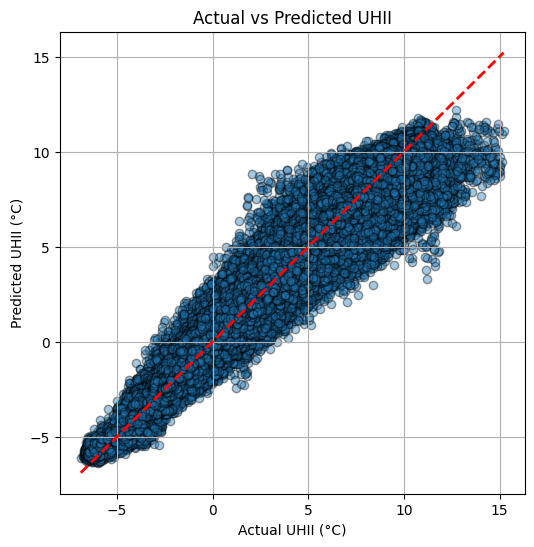

In [16]:
plt.figure(figsize=(6,6))
plt.scatter(y_true, test_preds_reg, alpha=0.4, edgecolor='k')
plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', lw=2)
plt.xlabel("Actual UHII (°C)")
plt.ylabel("Predicted UHII (°C)")
plt.title("Actual vs Predicted UHII")
plt.grid(True)
plt.show()


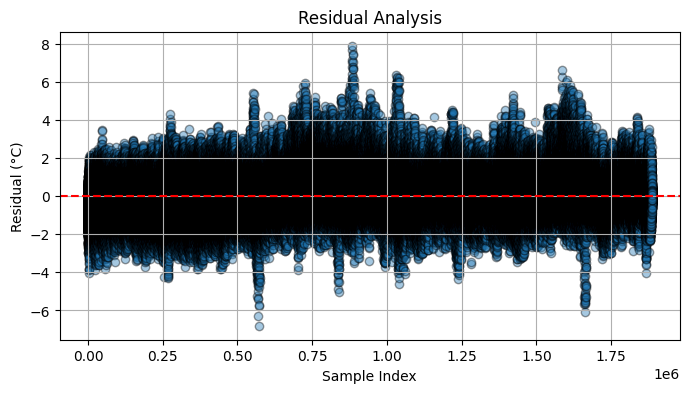

In [17]:
residuals = y_true - test_preds_reg
plt.figure(figsize=(8,4))
plt.scatter(range(len(residuals)), residuals, alpha=0.4, edgecolor='k')
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Sample Index")
plt.ylabel("Residual (°C)")
plt.title("Residual Analysis")
plt.grid(True)
plt.show()


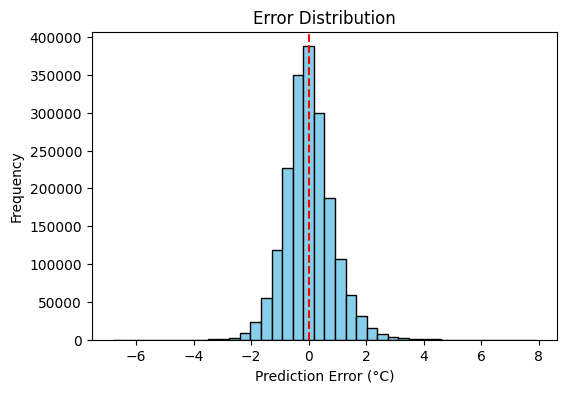

In [18]:
plt.figure(figsize=(6,4))
plt.hist(residuals, bins=40, color='skyblue', edgecolor='black')
plt.axvline(0, color='red', linestyle='--')
plt.xlabel("Prediction Error (°C)")
plt.ylabel("Frequency")
plt.title("Error Distribution")
plt.show()


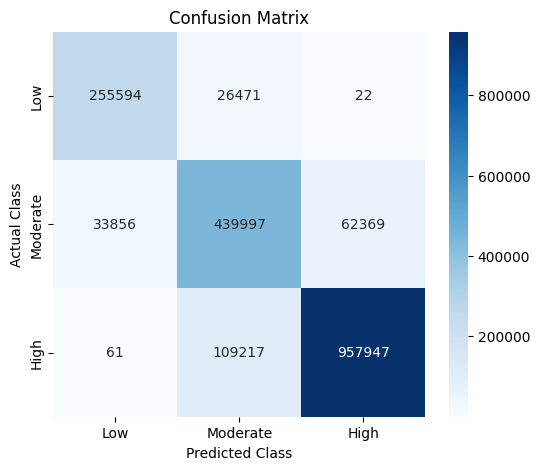

In [19]:
cm = confusion_matrix(y_true_clf, test_preds_clf)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues",
            xticklabels=['Low','Moderate','High'],
            yticklabels=['Low','Moderate','High'])
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Confusion Matrix")
plt.show()


C:\Users\Amrit Kaur\AppData\Local\Temp\ipykernel_22144\1049278547.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['Low','Moderate','High'], y=class_acc, palette="viridis")


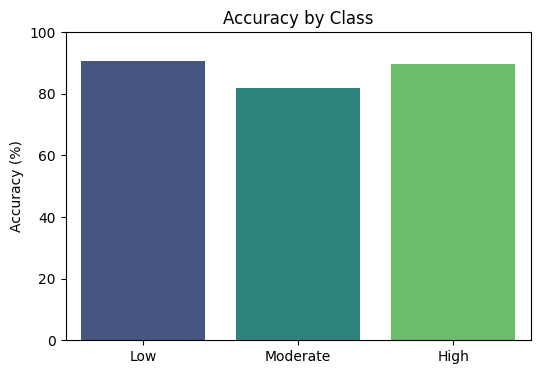

In [23]:
report = classification_report(y_true_clf, test_preds_clf, target_names=['Low','Moderate','High'], output_dict=True)
class_acc = [report[label]['recall']*100 for label in ['Low','Moderate','High']]

plt.figure(figsize=(6,4))
sns.barplot(x=['Low','Moderate','High'], y=class_acc, palette="viridis")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy by Class")
plt.ylim(0,100)
plt.show()


C:\Users\Amrit Kaur\AppData\Local\Temp\ipykernel_22144\1562694229.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=np.array(feature_order)[indices], x=importances[indices], palette="coolwarm")


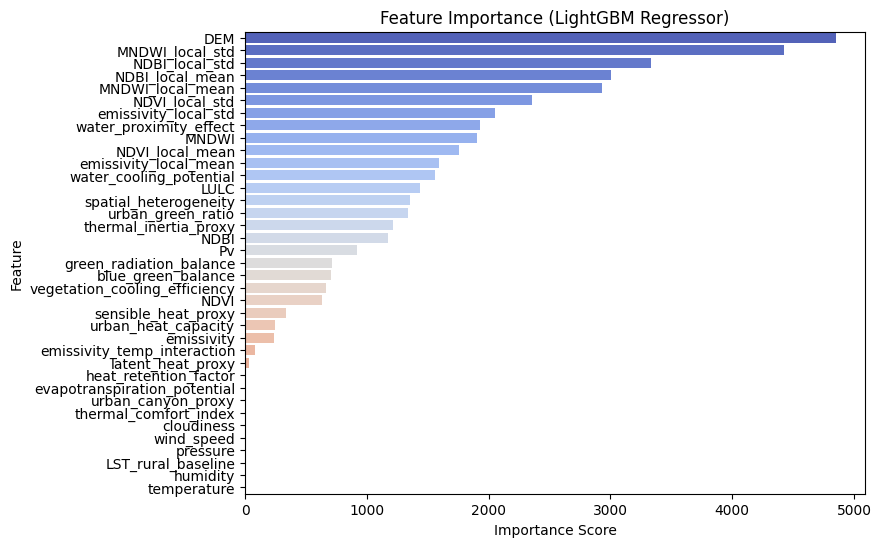

In [24]:
importances = reg_model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(8,6))
sns.barplot(y=np.array(feature_order)[indices], x=importances[indices], palette="coolwarm")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.title("Feature Importance (LightGBM Regressor)")
plt.show()


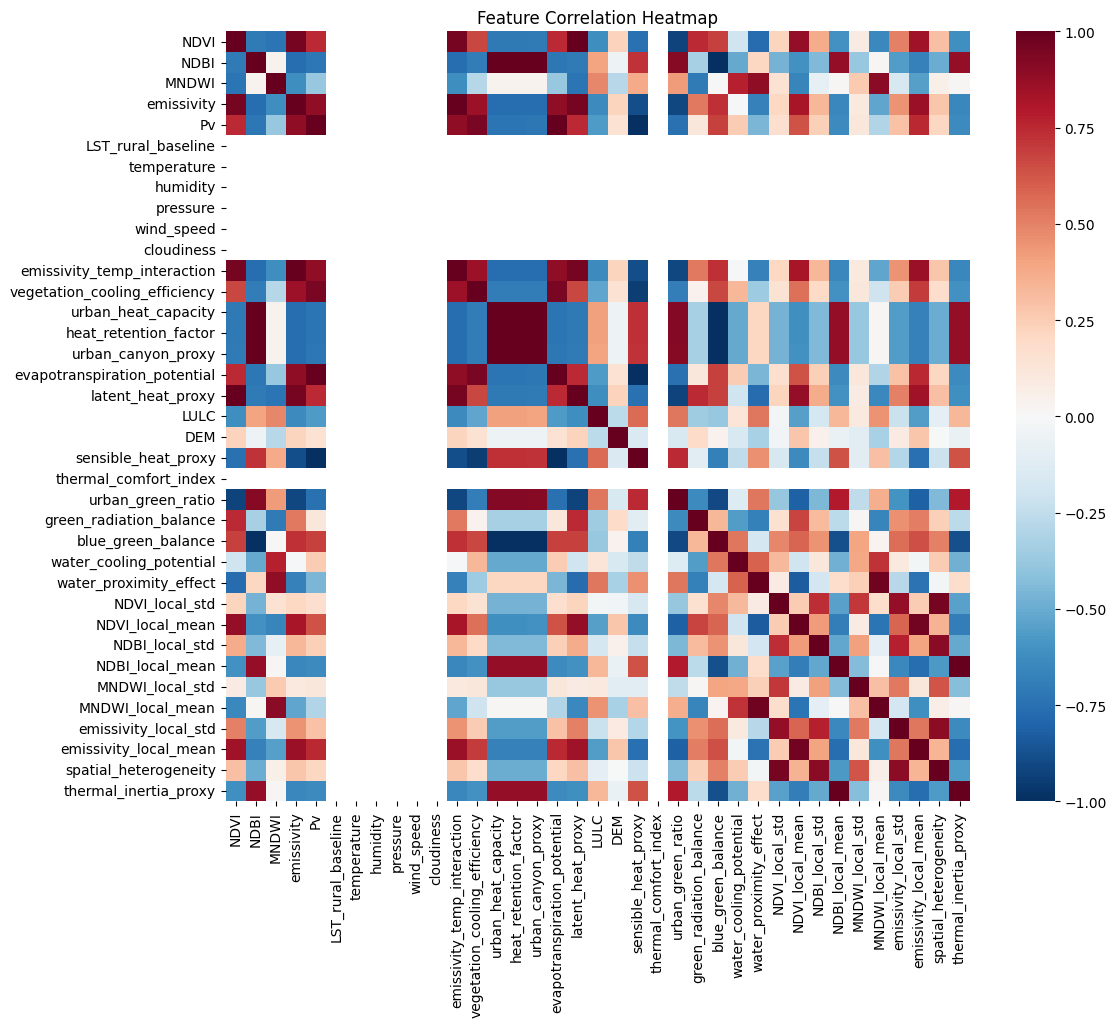

In [25]:
corr = df_test.corr()
plt.figure(figsize=(12,10))
sns.heatmap(corr, cmap="RdBu_r", center=0, annot=False)
plt.title("Feature Correlation Heatmap")
plt.show()
